In [60]:
import pandas as pd

In [61]:
data = pd.read_csv('../../data/US-pumpkins.csv')
columns_to_select = ['City Name', 'Package', 'Variety', 'Origin', 'Item Size', 'Color']

data = data.loc[:, columns_to_select]
data.dropna(inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 991 entries, 2 to 1698
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   City Name  991 non-null    str  
 1   Package    991 non-null    str  
 2   Variety    991 non-null    str  
 3   Origin     991 non-null    str  
 4   Item Size  991 non-null    str  
 5   Color      991 non-null    str  
dtypes: str(6)
memory usage: 54.2 KB


In [62]:
data.head()

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


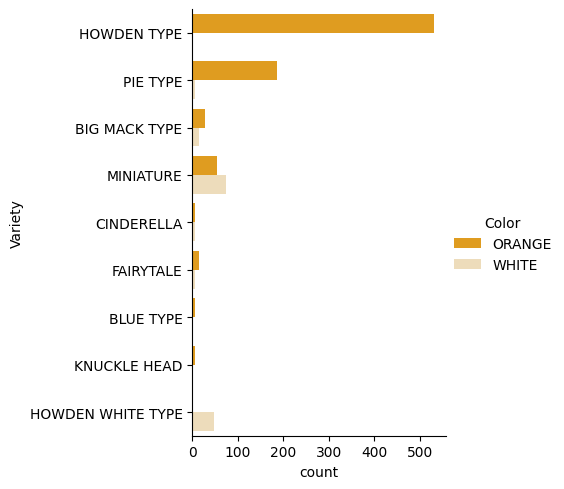

In [63]:
import seaborn as sns

palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}

sns.catplot(data=data, y="Variety", hue='Color', kind='count', palette=palette)

In [64]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
ordinal_features = ['Item Size']
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

categorical_features = ['City Name', 'Package', 'Variety', 'Origin']
categorical_encoder = OneHotEncoder(sparse_output=False)

In [65]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[
    ('ord', ordinal_encoder, ordinal_features),
    ('cat', categorical_encoder, categorical_features)
])

ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(data)

print(encoded_features)

      ord__Item Size  cat__City Name_ATLANTA  cat__City Name_BALTIMORE  \
2                1.0                     0.0                       1.0   
3                1.0                     0.0                       1.0   
4                3.0                     0.0                       1.0   
5                3.0                     0.0                       1.0   
6                1.0                     0.0                       1.0   
...              ...                     ...                       ...   
1694             4.0                     0.0                       0.0   
1695             4.0                     0.0                       0.0   
1696             4.0                     0.0                       0.0   
1697             4.0                     0.0                       0.0   
1698             4.0                     0.0                       0.0   

      cat__City Name_BOSTON  cat__City Name_CHICAGO  cat__City Name_COLUMBIA  \
2                       0.0    

In [66]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(data['Color'])
encoded_data = encoded_features.assign(Color=data['Color'])

print(encoded_data.head())

   ord__Item Size  cat__City Name_ATLANTA  cat__City Name_BALTIMORE  \
2             1.0                     0.0                       1.0   
3             1.0                     0.0                       1.0   
4             3.0                     0.0                       1.0   
5             3.0                     0.0                       1.0   
6             1.0                     0.0                       1.0   

   cat__City Name_BOSTON  cat__City Name_CHICAGO  cat__City Name_COLUMBIA  \
2                    0.0                     0.0                      0.0   
3                    0.0                     0.0                      0.0   
4                    0.0                     0.0                      0.0   
5                    0.0                     0.0                      0.0   
6                    0.0                     0.0                      0.0   

   cat__City Name_DALLAS  cat__City Name_DETROIT  cat__City Name_LOS ANGELES  \
2                    0.0      

/var/folders/c8/w5653zh95fv3vzdrz0pxdvc80000gn/T/ipykernel_15641/2648402759.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


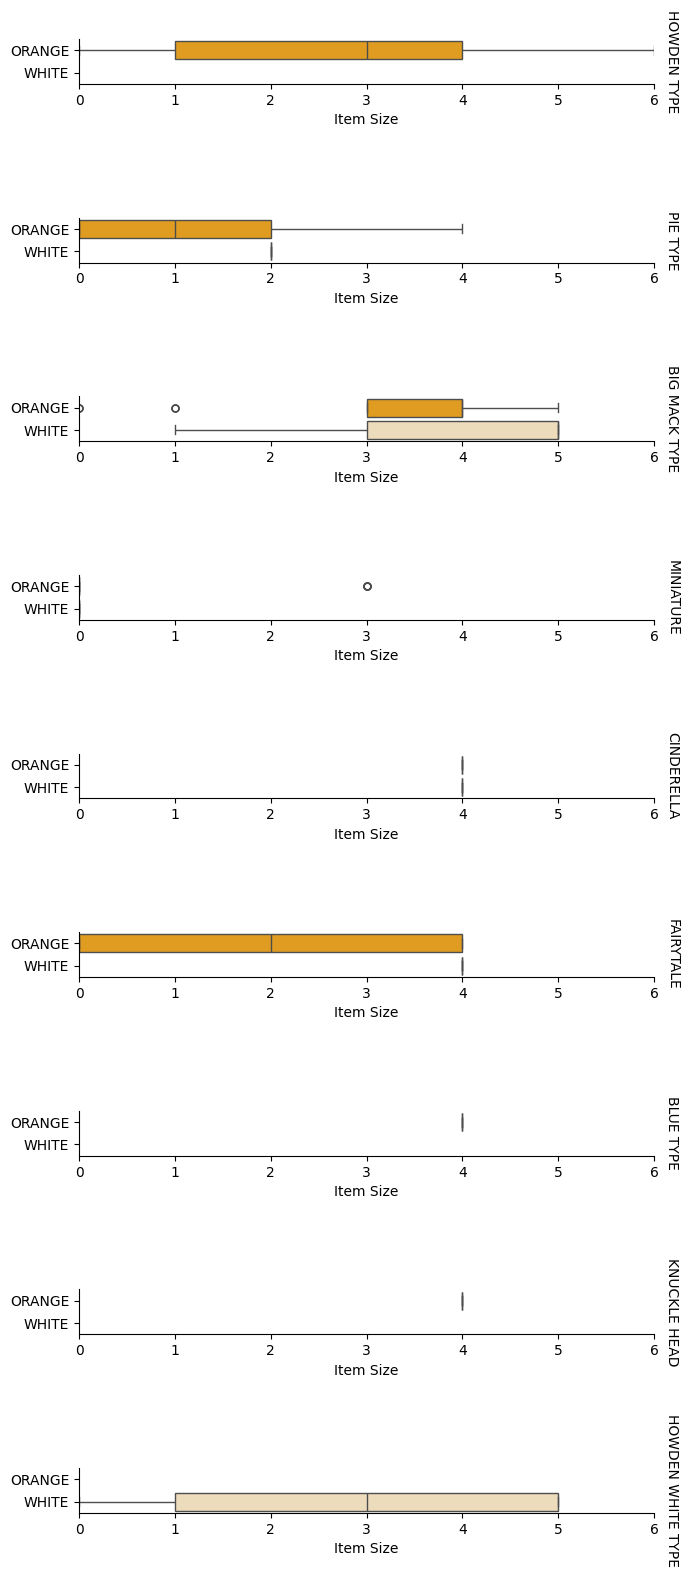

In [67]:
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}
data['Item Size'] = encoded_data['ord__Item Size']

g = sns.catplot(
    data=data,
    x="Item Size", y="Color", row='Variety',
    kind="box", orient="h",
    sharex=False, margin_titles=True,
    height=1.8, aspect=4, palette=palette,
)
g.set(xlabel="Item Size", ylabel="").set(xlim=(0,6))
g.set_titles(row_template="{row_name}")

/var/folders/c8/w5653zh95fv3vzdrz0pxdvc80000gn/T/ipykernel_15641/2373132385.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Color", y="ord__Item Size", data=encoded_data, palette=palette)
/Users/vitoramadhan/izzaalfiansyah/learning/ml-beginner/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 63.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/vitoramadhan/izzaalfiansyah/learning/ml-beginner/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 21.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Color', ylabel='ord__Item Size'>

/Users/vitoramadhan/izzaalfiansyah/learning/ml-beginner/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 79.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/vitoramadhan/izzaalfiansyah/learning/ml-beginner/.venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


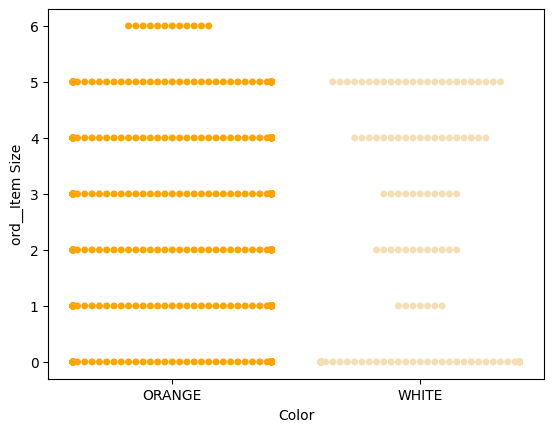

In [68]:
sns.swarmplot(x="Color", y="ord__Item Size", data=encoded_data, palette=palette)

In [69]:
from sklearn.model_selection import train_test_split

x = encoded_data[encoded_data.columns.difference(['Color'])]
y = encoded_data['Color']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))
print('Predicted labels :', y_pred)
print('F1-score:', f1_score(y_test, y_pred))

              precision    recall  f1-score   support

      ORANGE       0.94      0.98      0.96       166
       WHITE       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Predicted labels : ['ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE'
 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE'
 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'WHITE' 'ORANGE' 'ORANGE' 'WHITE'
 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE'
 'WHITE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE'
 'ORANGE' 'ORANGE' 'WHITE' 'ORANGE' 'WHITE' 'ORANGE' 'ORANGE' 'WHITE'
 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'WHITE' 'ORANGE' 'WHITE'
 'ORANGE' 'WHITE' 'ORANGE' 'WHITE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE'
 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE' 'ORANGE'
 'ORANG

ValueError: pos_label=1 is not a valid label. It should be one of ['ORANGE', 'WHITE']